## **Shivprasad A. Mahind (123B1B266)**

# **1. Introduction to K-Nearest Neighbors (KNN)**
The K-Nearest Neighbors (KNN) algorithm is a simple yet powerful supervised machine learning algorithm used for both classification and regression. It's known as an instance-based or lazy learning algorithm.

**Instance-Based:** It doesn't learn a discriminative function from the training data but instead memorizes the entire training dataset.

**Lazy Learning:** It does no work during the training phase. All the computation is deferred until a prediction is requested.

The core idea is intuitive and can be summarized as: "A data point is likely to be similar to the points closest to it." For classification, KNN assigns a class to a new data point based on a majority vote of its 'k' nearest neighbors. 🗳️

# **2. The KNN Prediction Process**
When the model is asked to predict the class for a new, unseen data point, it follows these steps:

**Calculate Distance:** The algorithm calculates the distance between the new data point and every single point in the memorized training dataset. The most common distance metric used is the Euclidean distance.


**Find Neighbors:** It then identifies the top 'k' data points from the training set that are closest to the new point (the "nearest neighbors").

**Majority Vote:** The algorithm looks at the class labels of these 'k' neighbors and assigns the most common class to the new data point. For example, if k=3 and two neighbors are 'versicolor' and one is 'virginica', the new point will be classified as 'versicolor'.

This process makes the choice of 'k' a critical hyperparameter.

# **3. The Importance of the Hyperparameter 'k'**
The number of neighbors, k, determines the model's complexity and how it creates the decision boundary. Choosing the right k is essential for balancing the bias-variance trade-off.

**Low k (e.g., k=1):** The model is highly flexible and sensitive to noise. The decision boundary can be very jagged and irregular. This can lead to high variance and overfitting, where the model learns the noise in the training data instead of the underlying pattern.

**High k (e.g., k=25):** The model is less flexible and the decision boundary becomes much smoother. It is more resistant to noise but may fail to capture the local structure of the data. This can lead to high bias and underfitting, where the model is too simple to represent the true relationship in the data.


In [ ]:
# 1. Import necessary libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 2. Load the Iris dataset
# The dataset is included with the scikit-learn library
iris = load_iris()
X = iris.data  # Features: sepal length, sepal width, petal length, petal width
y = iris.target # Target variable: species of the iris

# 3. Split the data into training and testing sets
# We'll use 80% of the data to train the model and 20% to test it.
# random_state ensures that the split is the same every time you run the code.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and train the classifier
# We'll use a K-Nearest Neighbors classifier with k=3
knn = KNeighborsClassifier(n_neighbors=3)

# Train the model using the training data
knn.fit(X_train, y_train)

# 5. Make predictions on the test data
y_pred = knn.predict(X_test)

# 6. Evaluate the model's performance
# We check how many predictions were correct.
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# 7. Example: Predict a new flower's species
# Let's say we have a new flower with the following measurements:
# Sepal length = 5.1 cm, Sepal width = 3.5 cm, Petal length = 1.4 cm, Petal width = 0.2 cm
new_flower_data = [[5.1, 3.5, 1.4, 0.2]]

# Predict the species
prediction = knn.predict(new_flower_data)

# Print the result
predicted_species_name = iris.target_names[prediction[0]]
print(f"The predicted species for the new flower is: {predicted_species_name}")

Model Accuracy: 100.00%
The predicted species for the new flower is: setosa


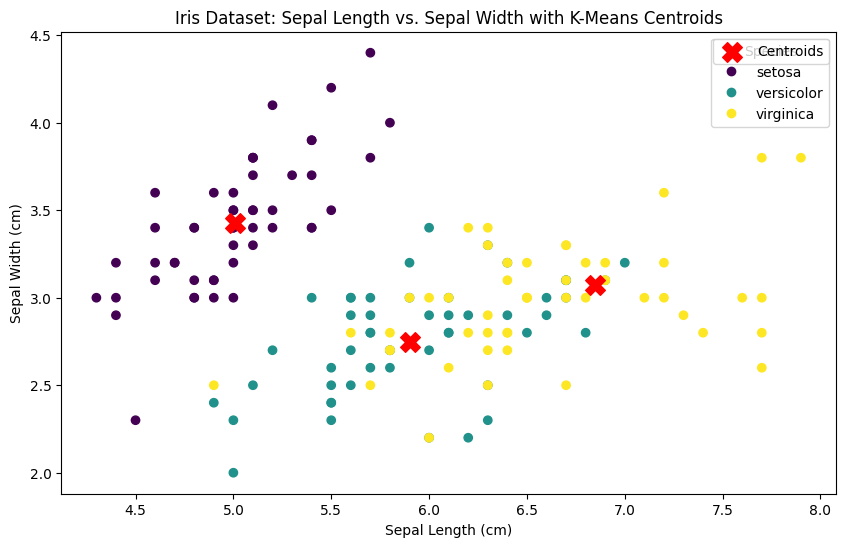

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Create a scatter plot of the first two features, colored by species
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Iris Dataset: Sepal Length vs. Sepal Width with K-Means Centroids')

# Add a legend for the species
legend1 = plt.legend(*scatter.legend_elements(), title="Species")
for i, text in enumerate(legend1.get_texts()):
    text.set_text(iris.target_names[i])
plt.gca().add_artist(legend1) # Add the first legend back to the plot

# Perform K-Means clustering
# We know there are 3 species in the Iris dataset, so we'll use n_clusters=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # Added n_init for versions >= 1.2
kmeans.fit(X)
centroids = kmeans.cluster_centers_

# Plot the centroids
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, c='red', label='Centroids')

# Add a legend for the centroids
plt.legend()

plt.show()